# 14.06 — Final Held-Out Evaluation on Frozen Test Split

This notebook presents the final, un-tuned research benchmark across all 111 canonical skills evaluated on the **strictly frozen held-out test split** ($N=636$).

### Benchmark Scope:
1. **Keyword Baseline:** Deterministic surface-form & alias classifier.
2. **TF-IDF + Cosine Centroids:** Fast sublinear lexical baseline.
3. **Pretrained MiniLM (all-MiniLM-L6-v2):** 384-dimensional dense semantic prototypes without domain fine-tuning.
4. **Fine-Tuned MiniLM:** Supervised contrastively adapted semantic model.
5. **Final Production Hybrid Topic Extractor:** Multi-tiered architecture with calibrated confidence/margin gating and safe abstention.


In [1]:
import sys
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FINAL_METRICS_FILE = PROJECT_ROOT / 'artifacts' / 'topic_extractor' / 'final_test_metrics.json'

with open(FINAL_METRICS_FILE, 'r', encoding='utf-8') as f:
    final_data = json.load(f)

benchmarks = final_data['benchmarks']
hybrid = benchmarks['hybrid_topic_extractor']
print(f"Loaded final test metrics for {final_data['dataset']['samples']} samples across {final_data['dataset']['skills']} skills.")


Loaded final test metrics for 636 samples across 111 skills.


## 1. Held-Out Test Set Performance Benchmark

In [2]:
summary_rows = [
    {
        'Model Architecture': '1. Keyword / Rule Baseline',
        'Top-1 Accuracy': f"{benchmarks['keyword_baseline']['accuracy']*100:.2f}%",
        'Top-3 Accuracy': 'N/A',
        'Macro F1': f"{benchmarks['keyword_baseline']['macro_f1']:.4f}",
        'Coverage': f"{benchmarks['keyword_baseline']['coverage']*100:.2f}%",
        'Covered Accuracy': f"{benchmarks['keyword_baseline']['covered_accuracy']*100:.2f}%",
        'Abstention Rate': f"{(1 - benchmarks['keyword_baseline']['coverage'])*100:.2f}%",
    },
    {
        'Model Architecture': '2. TF-IDF + Cosine Prototypes',
        'Top-1 Accuracy': f"{benchmarks['tfidf_baseline']['accuracy']*100:.2f}%",
        'Top-3 Accuracy': f"{benchmarks['tfidf_baseline']['top3_accuracy']*100:.2f}%",
        'Macro F1': f"{benchmarks['tfidf_baseline']['macro_f1']:.4f}",
        'Coverage': '100.00%',
        'Covered Accuracy': f"{benchmarks['tfidf_baseline']['accuracy']*100:.2f}%",
        'Abstention Rate': '0.00%',
    },
    {
        'Model Architecture': '3. Pretrained MiniLM (Base)',
        'Top-1 Accuracy': f"{benchmarks['minilm_pretrained']['accuracy']*100:.2f}%",
        'Top-3 Accuracy': f"{benchmarks['minilm_pretrained']['top3_accuracy']*100:.2f}%",
        'Macro F1': f"{benchmarks['minilm_pretrained']['macro_f1']:.4f}",
        'Coverage': '100.00%',
        'Covered Accuracy': f"{benchmarks['minilm_pretrained']['accuracy']*100:.2f}%",
        'Abstention Rate': '0.00%',
    },
    {
        'Model Architecture': '4. Fine-Tuned MiniLM (Domain Adapted)',
        'Top-1 Accuracy': f"{benchmarks['minilm_finetuned']['accuracy']*100:.2f}%",
        'Top-3 Accuracy': f"{benchmarks['minilm_finetuned']['top3_accuracy']*100:.2f}%",
        'Macro F1': f"{benchmarks['minilm_finetuned']['macro_f1']:.4f}",
        'Coverage': '100.00%',
        'Covered Accuracy': f"{benchmarks['minilm_finetuned']['accuracy']*100:.2f}%",
        'Abstention Rate': '0.00%',
    },
    {
        'Model Architecture': '5. Production Hybrid Extractor (Calibrated)',
        'Top-1 Accuracy': f"{hybrid['accuracy']*100:.2f}%",
        'Top-3 Accuracy': f"{hybrid['top3_accuracy']*100:.2f}%",
        'Macro F1': f"{hybrid['macro_f1']:.4f}",
        'Coverage': f"{hybrid['coverage']*100:.2f}%",
        'Covered Accuracy': f"{hybrid['covered_accuracy']*100:.2f}%",
        'Abstention Rate': f"{hybrid['abstention_rate']*100:.2f}%",
    },
]

benchmark_df = pd.DataFrame(summary_rows)
display(benchmark_df)


,Model Architecture,Top-1 Accuracy,Top-3 Accuracy,Macro F1,Coverage,Covered Accuracy,Abstention Rate
0,1. Keyword / Rule Baseline,86.16%,N/A,0.8854,87.11%,98.92%,12.89%
1,2. TF-IDF + Cosine Prototypes,97.01%,98.58%,0.9752,100.00%,97.01%,0.00%
2,3. Pretrained MiniLM (Base),93.55%,98.58%,0.9376,100.00%,93.55%,0.00%
3,4. Fine-Tuned MiniLM (Domain Adapted),98.90%,99.37%,0.9900,100.00%,98.90%,0.00%
4,5. Production Hybrid Extractor (Calibrated),96.86%,98.27%,0.9719,98.43%,98.40%,1.57%


## 2. Comparative Benchmark Visualizations

C:\Users\mathu\AppData\Local\Temp\ipykernel_9016\1138613980.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(models, fontsize=9, rotation=12)


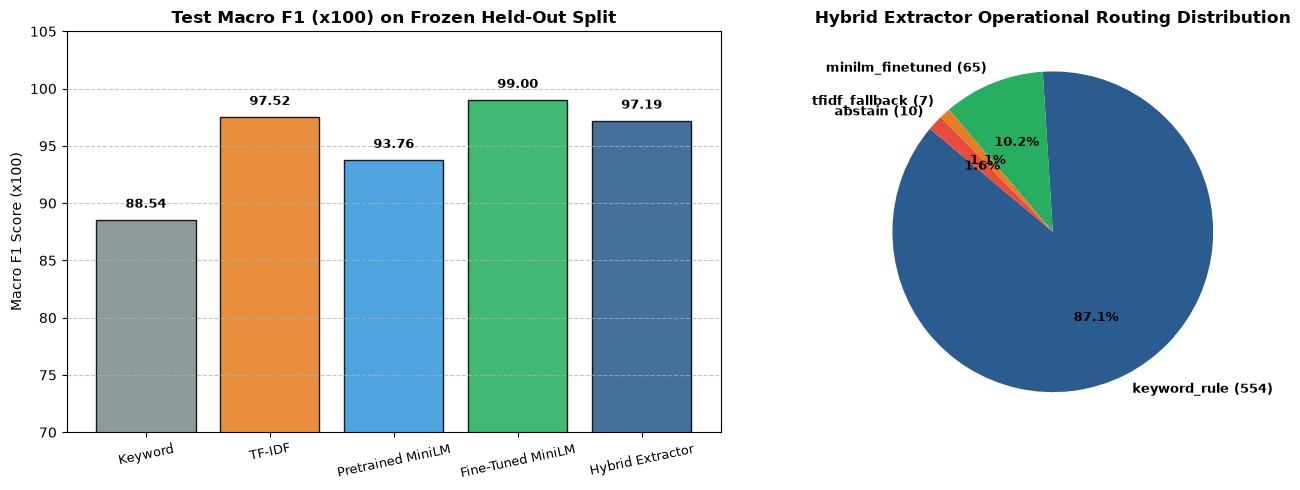

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = ['Keyword', 'TF-IDF', 'Pretrained MiniLM', 'Fine-Tuned MiniLM', 'Hybrid Extractor']
macro_f1s = [
    benchmarks['keyword_baseline']['macro_f1'] * 100,
    benchmarks['tfidf_baseline']['macro_f1'] * 100,
    benchmarks['minilm_pretrained']['macro_f1'] * 100,
    benchmarks['minilm_finetuned']['macro_f1'] * 100,
    hybrid['macro_f1'] * 100,
]

bars = ax1.bar(models, macro_f1s, color=['#7f8c8d', '#e67e22', '#3498db', '#27ae60', '#2b5c8f'], edgecolor='black', alpha=0.88)
ax1.set_title('Test Macro F1 (x100) on Frozen Held-Out Split', fontsize=12, fontweight='bold')
ax1.set_ylabel('Macro F1 Score (x100)', fontsize=10)
ax1.set_xticklabels(models, fontsize=9, rotation=12)
ax1.set_ylim(70, 105)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for b in bars:
    y = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, y + 0.8, f'{y:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Method usage in hybrid
method_labels = list(hybrid['method_breakdown'].keys())
method_counts = list(hybrid['method_breakdown'].values())
colors = ['#2b5c8f', '#27ae60', '#e67e22', '#e74c3c']

pie_labels = [str(l) + ' (' + str(c) + ')' for l, c in zip(method_labels, method_counts)]
ax2.pie(method_counts, labels=pie_labels, autopct='%1.1f%%', colors=colors[:len(method_labels)], startangle=140, textprops={'fontsize': 9, 'fontweight': 'bold'})
ax2.set_title('Hybrid Extractor Operational Routing Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Skill-Level F1 Score Distribution

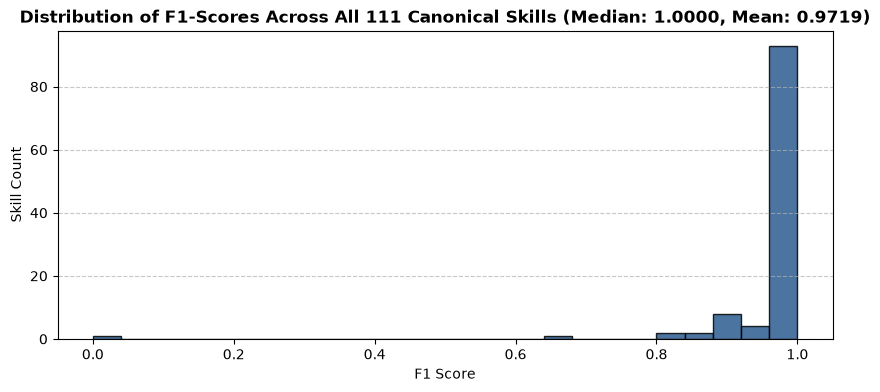

In [4]:
per_skill = final_data['per_skill_metrics']
f1_values = [v['f1'] for v in per_skill.values()]

plt.figure(figsize=(10, 4))
plt.hist(f1_values, bins=25, color='#2b5c8f', edgecolor='black', alpha=0.85)
plt.title(f'Distribution of F1-Scores Across All 111 Canonical Skills (Median: {np.median(f1_values):.4f}, Mean: {np.mean(f1_values):.4f})', fontsize=12, fontweight='bold')
plt.xlabel('F1 Score', fontsize=10)
plt.ylabel('Skill Count', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
